A communication channel introduces interference into a transmitted signal. The transmitted signal is a carrier tone:

$x_1(n)=cos⁡(2\pi(5)t)$

Two interference components corrupt it:

$x_2(n)=0.8cos⁡(2\pi(60)t)$

$x_3(n)=0.4cos⁡(2\pi(150)t)$

$x(n)=x_1(n)+x_2(n)+x_3(n)x(n)$

Use a sampling rate of 500 Hz over 1.5 seconds.
a. Plot $x(n)$ and identify how the interference masks the carrier.

b. Design a 15-point moving average filter $h(n)$ and manually implement y(n)=x(n)∗h(n). Plot y(n) alongside x(n).

c. Compute and plot the magnitude spectrum of both x(n) and y(n) using the DFT. What does the filter do to the interference frequencies?

In [234]:
import numpy as np
import matplotlib.pyplot as plt

In [235]:
# Parameters

start = 0
end = 1.5
f1 = 5
f2 = 60
f3 = 150
fs = 500
kernel_no = 15
t = np.arange(start, end, 1/fs)

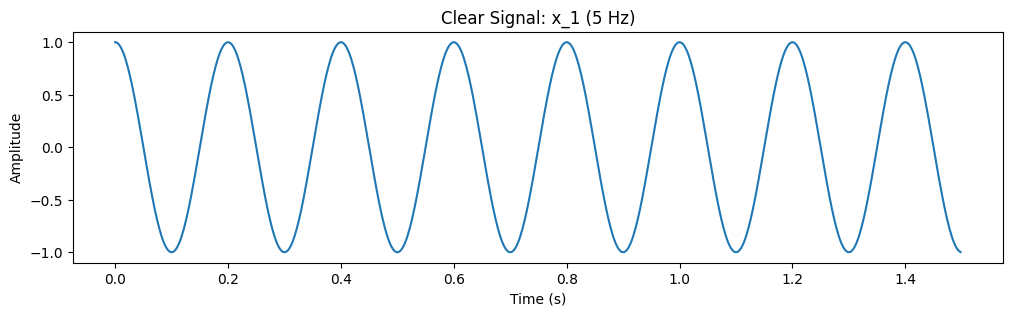

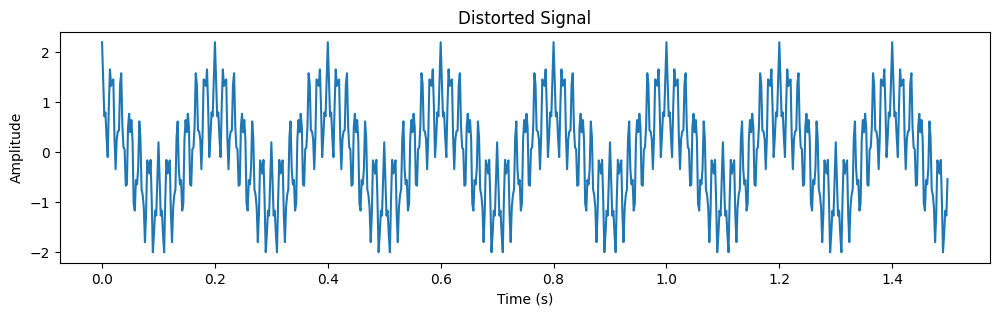

In [236]:
# Signals

x_1 = np.cos(2 * np.pi *f1 * t)
x_2 = 0.8 * np.cos(2 * np.pi *f2 * t)
x_3 = 0.4 * np.cos(2 * np.pi *f3 * t)
x = x_1 + x_2 + x_3
h = np.ones(kernel_no) / kernel_no

# Plots
plt.figure(figsize=(12, 3))
plt.plot(t, x_1)
plt.ylabel('Amplitude')
plt.xlabel('Time (s)')
plt.title('Clear Signal: x_1 (5 Hz)')
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(t, x)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title('Distorted Signal')
plt.show()


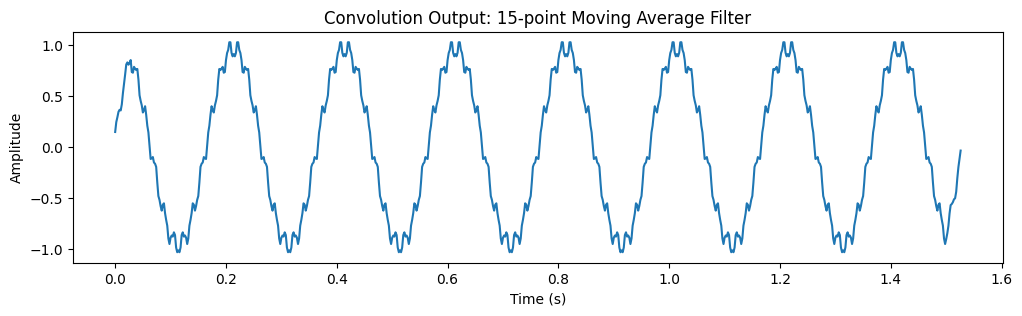

In [237]:
# Convolution [Manual]
conv_length = len(x) + len(h) - 1
y = np.zeros(conv_length)

for n in range(conv_length):
    for k in range(len(x)):
        j = n - k      
        if j >=0 and j < len(h):
            y[n] += x[k] * h[j]

# Output
plt.figure(figsize=(12, 3))
plt.title('Convolution Output: 15-point Moving Average Filter')
plt.plot(np.arange(0, len(y)/fs, 1/fs), y)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

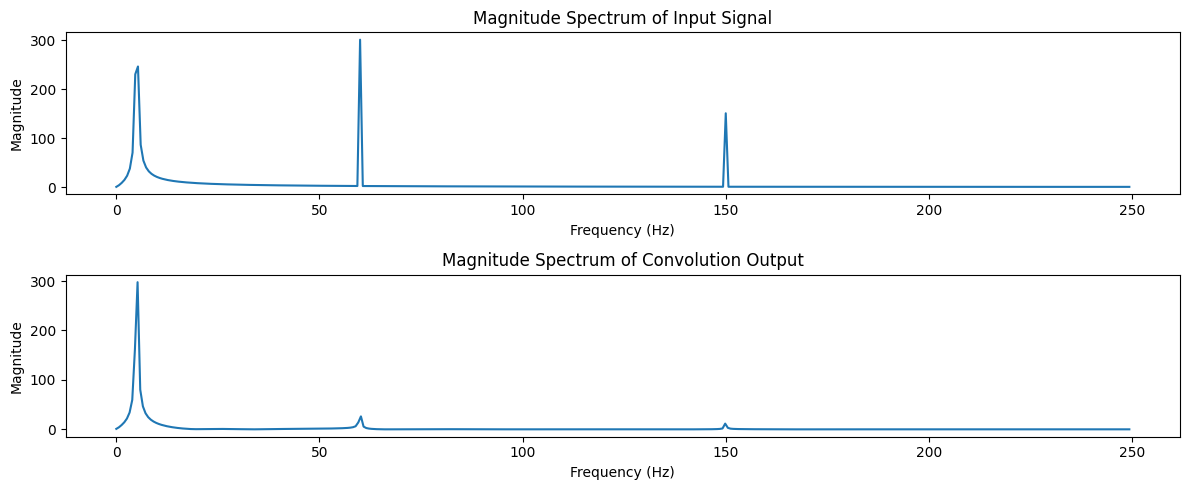

In [238]:
# Magnitude Spectrum

X = np.fft.fft(x)
Y = np.fft.fft(y)
freqs1 = np.fft.fftfreq(len(x), 1/fs)
freqs2 = np.fft.fftfreq(len(y), 1/fs)

plt.figure(figsize=(12, 5))
plt.subplot(2, 1, 1)
plt.plot(freqs1[:len(freqs1)//2], np.abs(X[:len(X)//2]))  # Plotting one-sided spectrum
plt.title('Magnitude Spectrum of Input Signal')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.subplot(2, 1, 2)
plt.plot(freqs2[:len(freqs2)//2], np.abs(Y[:len(Y)//2]))  # Plotting one-sided spectrum
plt.title('Magnitude Spectrum of Convolution Output')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.tight_layout()
plt.show()



- As seen, the filter attenuates the high frequency components in the signal. Basically, a low pass filter.